In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

In [2]:
tickers = ['AAPL', 'MSFT', 'JPM', 'XOM', 'GLD']
prices=yf.download(tickers, start='2021-01-01', end='2026-01-01', auto_adjust=True)
close_prices = prices['Close']
returns = close_prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


In [3]:
mean_returns = returns.mean()
mean_returns

Ticker
AAPL    0.000767
GLD     0.000668
JPM     0.000970
MSFT    0.000800
XOM     0.001155
dtype: float64

In [4]:
annual_returns = mean_returns * 252
annual_returns

Ticker
AAPL    0.193226
GLD     0.168268
JPM     0.244470
MSFT    0.201725
XOM     0.291140
dtype: float64

In [5]:
annual_covariance_matrix = returns.cov() * 252
annual_covariance_matrix

Ticker,AAPL,GLD,JPM,MSFT,XOM
Ticker,,,,,
AAPL,0.077633,0.003093,0.023363,0.045421,0.014262
GLD,0.003093,0.024384,0.000490,0.002852,0.005916
JPM,0.023363,0.000490,0.058926,0.019430,0.023862
MSFT,0.045421,0.002852,0.019430,0.066123,0.005890
XOM,0.014262,0.005916,0.023862,0.005890,0.073027


In [6]:
def portfolio_returns(weights):
    return np.dot(weights, annual_returns)

In [7]:
def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(annual_covariance_matrix, weights)))


In [8]:
equal_weights = np.array([1/len(tickers)] * len(tickers))


In [9]:
portfolio_return = portfolio_returns(equal_weights)
portfolio_volatility = portfolio_volatility(equal_weights)

In [10]:
portfolio_return, portfolio_volatility

(np.float64(0.21976583606691716), np.float64(0.15352528253998474))

In [11]:
def portfolio_variance(weights):
    return np.dot(weights.T, np.dot(annual_covariance_matrix, weights))

In [12]:
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(tickers)))

In [13]:
initial_weights=equal_weights.copy()

In [14]:
minimum_variance_result = minimize(portfolio_variance, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
minimum_variance_weights = minimum_variance_result.x
minimum_variance_weights

array([0.02815231, 0.58287733, 0.15425943, 0.13739632, 0.09731462])

In [15]:
minimum_variance_weights.sum()

np.float64(1.0)

In [16]:
def portfolio_return(weights):
    return np.dot(weights, annual_returns)
type(portfolio_return)


function

In [17]:
minimum_variance_return = portfolio_return(minimum_variance_weights)


In [18]:
covariance_matrix = returns.cov()
annual_covariance = covariance_matrix * 252

In [19]:
mean_returns = returns.mean()
annual_returns = mean_returns * 252

In [20]:
def portfolio_return(weights):
    return np.dot(weights, annual_returns)


def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(weights.T, np.dot(annual_covariance, weights))
    )

In [21]:
minimum_variance_return = portfolio_return(minimum_variance_weights)

minimum_variance_volatility = portfolio_volatility(minimum_variance_weights)
minimum_variance_return, minimum_variance_volatility

(np.float64(0.19727955082719822), np.float64(0.12383693073782237))

In [22]:
pd.Series(minimum_variance_weights, index=tickers)

AAPL    0.028152
MSFT    0.582877
JPM     0.154259
XOM     0.137396
GLD     0.097315
dtype: float64

In [23]:
risk_free_rate = 0.0

def portfolio_sharpe(weights):
    portfolio_ret = portfolio_return(weights)
    portfolio_vol = portfolio_volatility(weights)
    
    return (portfolio_ret - risk_free_rate) / portfolio_vol

In [24]:
def negative_sharpe(weights):
    return -portfolio_sharpe(weights)

In [25]:
maximum_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

In [26]:
maximum_sharpe_weights = maximum_sharpe_result.x
pd.Series(maximum_sharpe_weights, index=tickers)

AAPL    4.035982e-19
MSFT    4.676532e-01
JPM     1.911583e-01
XOM     1.431712e-01
GLD     1.980173e-01
dtype: float64

In [27]:
maximum_sharpe_return = portfolio_return(maximum_sharpe_weights)

maximum_sharpe_volatility = portfolio_volatility(maximum_sharpe_weights)

maximum_sharpe_ratio = portfolio_sharpe(maximum_sharpe_weights)

maximum_sharpe_return, maximum_sharpe_volatility, maximum_sharpe_ratio

(np.float64(0.2119554650551108),
 np.float64(0.12835132940810384),
 np.float64(1.6513694562615753))

In [28]:
num_portfolios = 5000

portfolio_returns = []
portfolio_volatilities = []
portfolio_weights = []

In [29]:
for _ in range(num_portfolios):
    
    weights = np.random.random(len(tickers))
    weights = weights / np.sum(weights)
    
    portfolio_weights.append(weights)
    portfolio_returns.append(portfolio_return(weights))
    portfolio_volatilities.append(portfolio_volatility(weights))

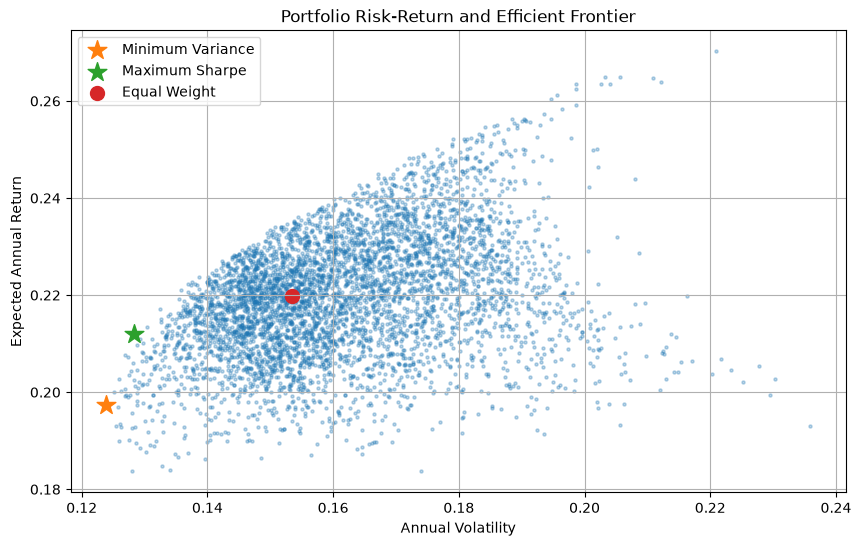

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(portfolio_volatilities,portfolio_returns,s=5,alpha=0.3)

plt.scatter(minimum_variance_volatility,minimum_variance_return,marker='*',s=200,label='Minimum Variance')

plt.scatter(maximum_sharpe_volatility,maximum_sharpe_return,marker='*',s=200,label='Maximum Sharpe')

plt.scatter(portfolio_volatility(equal_weights),portfolio_return(equal_weights),marker='o',s=100,label='Equal Weight')

plt.xlabel('Annual Volatility')
plt.ylabel('Expected Annual Return')
plt.title('Portfolio Risk-Return and Efficient Frontier')
plt.legend()
plt.grid(True)

plt.show()

In [31]:
target_returns = np.linspace(minimum_variance_return, annual_returns.max(),50)

efficient_volatilities = []
efficient_returns = []

In [32]:
for target_return in target_returns:

    frontier_constraints = ({'type': 'eq','fun': lambda weights: np.sum(weights) - 1},
        {'type': 'eq','fun': lambda weights, target_return=target_return:portfolio_return(weights) - target_return})

    result = minimize(portfolio_variance,initial_weights,method='SLSQP',bounds=bounds,constraints=frontier_constraints)

    if result.success:
        efficient_returns.append(target_return)
        efficient_volatilities.append(portfolio_volatility(result.x))

In [33]:
len(efficient_returns), len(efficient_volatilities)

(50, 50)

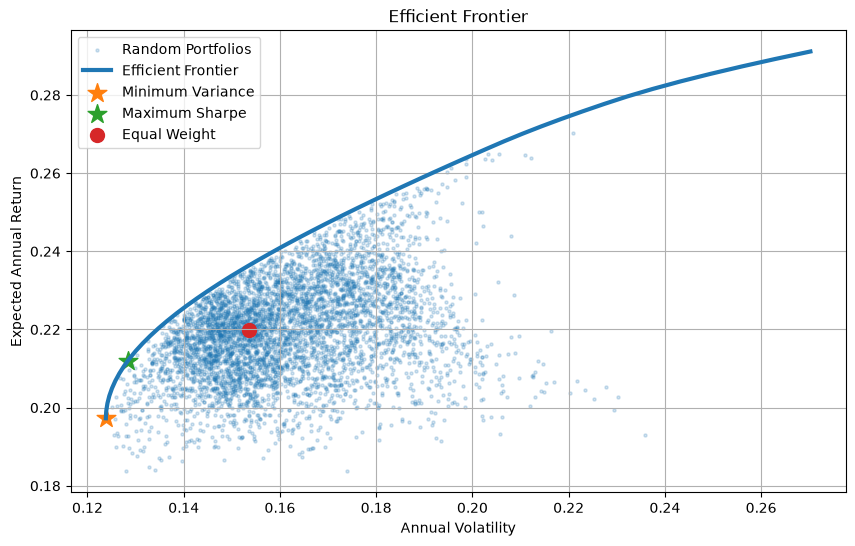

In [34]:
plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    s=5,
    alpha=0.2,
    label='Random Portfolios'
)

# Efficient frontier
plt.plot(
    efficient_volatilities,
    efficient_returns,
    linewidth=3,
    label='Efficient Frontier'
)

# Minimum-variance portfolio
plt.scatter(
    minimum_variance_volatility,
    minimum_variance_return,
    marker='*',
    s=200,
    label='Minimum Variance'
)

# Maximum-Sharpe portfolio
plt.scatter(
    maximum_sharpe_volatility,
    maximum_sharpe_return,
    marker='*',
    s=200,
    label='Maximum Sharpe'
)

# Equal-weight portfolio
plt.scatter(
    portfolio_volatility(equal_weights),
    portfolio_return(equal_weights),
    marker='o',
    s=100,
    label='Equal Weight'
)

plt.xlabel('Annual Volatility')
plt.ylabel('Expected Annual Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)

plt.show()

In [35]:
comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ],
    "Expected Return": [
        portfolio_return(equal_weights),
        minimum_variance_return,
        maximum_sharpe_return
    ],
    "Volatility": [
        portfolio_volatility(equal_weights),
        minimum_variance_volatility,
        maximum_sharpe_volatility
    ],
    "Sharpe Ratio": [
        portfolio_sharpe(equal_weights),
        portfolio_sharpe(minimum_variance_weights),
        portfolio_sharpe(maximum_sharpe_weights)
    ]
})

comparison

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Equal Weight,0.219766,0.153525,1.431463
1,Minimum Variance,0.197280,0.123837,1.593059
2,Maximum Sharpe,0.211955,0.128351,1.651369


In [36]:
comparison_formatted = comparison.copy()

comparison_formatted["Expected Return"] = (
    comparison_formatted["Expected Return"] * 100
).round(2).astype(str) + "%"

comparison_formatted["Volatility"] = (
    comparison_formatted["Volatility"] * 100
).round(2).astype(str) + "%"

comparison_formatted["Sharpe Ratio"] = (
    comparison_formatted["Sharpe Ratio"]
).round(2)

comparison_formatted

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Equal Weight,21.98%,15.35%,1.43
1,Minimum Variance,19.73%,12.38%,1.59
2,Maximum Sharpe,21.2%,12.84%,1.65


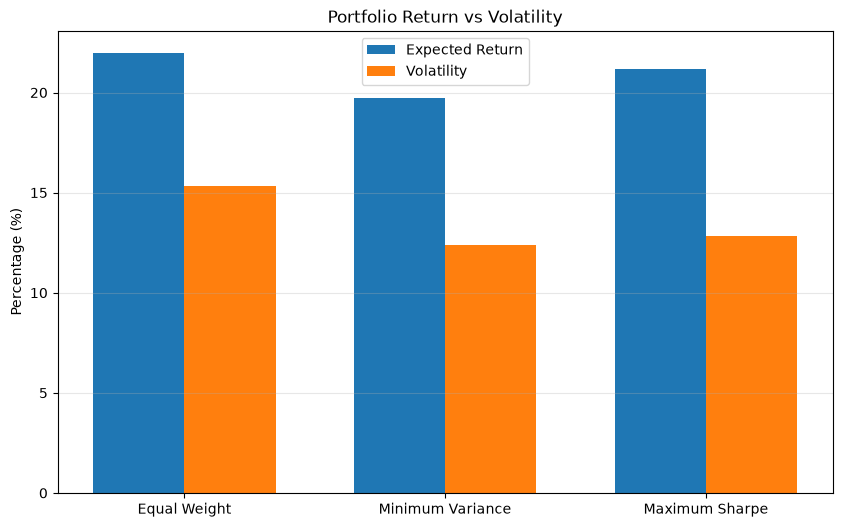

In [37]:
plt.figure(figsize=(10, 6))

x = np.arange(len(comparison["Portfolio"]))
width = 0.35

plt.bar(
    x - width/2,
    comparison["Expected Return"] * 100,
    width,
    label="Expected Return"
)

plt.bar(
    x + width/2,
    comparison["Volatility"] * 100,
    width,
    label="Volatility"
)

plt.xticks(x, comparison["Portfolio"])
plt.ylabel("Percentage (%)")
plt.title("Portfolio Return vs Volatility")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# Conclusions

This project analysed the risk and return characteristics of a portfolio containing AAPL, GLD, JPM, MSFT and XOM using historical daily price data from 2021 to 2025.

The analysis showed that diversification can significantly affect portfolio risk. Although individual assets had different levels of volatility and different correlations with one another, combining them into a portfolio reduced the overall risk compared with simply considering the assets independently.

The equal-weight portfolio produced an expected annual return of approximately 21.98% and annual volatility of 15.35%. This provided a useful benchmark for comparing the optimised portfolios.

The minimum-variance optimisation produced a portfolio with an expected annual return of approximately 19.73% and volatility of 12.38%. This demonstrates that portfolio risk could be reduced substantially while still maintaining a relatively high expected return.

The maximum-Sharpe portfolio produced an expected annual return of approximately 21.20% and volatility of 12.84%, giving it the highest Sharpe ratio of approximately 1.65. Compared with the equal-weight portfolio, it achieved a similar expected return while taking considerably less risk.

The optimisation also resulted in different asset allocations. The maximum-Sharpe portfolio allocated the largest weight to MSFT, followed by GLD, JPM and XOM, while AAPL received a weight of zero. This highlights how optimisation can produce very different portfolio allocations compared with an equal-weight strategy.

The efficient frontier further demonstrated the relationship between expected return and portfolio risk. Portfolios on the efficient frontier provide the highest expected return for a given level of risk, illustrating the importance of considering both return and volatility when constructing a portfolio.

Overall, the project demonstrates how quantitative methods can be used to analyse portfolio risk, measure downside risk and construct portfolios based on specific objectives. The results also show that the portfolio with the highest expected return is not necessarily the most attractive portfolio when risk is taken into account.

However, these results are based on historical data and therefore should not be interpreted as predictions of future performance. The optimisation assumes that historical returns, volatility and correlations provide useful estimates of future behaviour. Transaction costs, taxes, liquidity constraints and changing market conditions were also not included. The Sharpe ratio calculation additionally assumes a risk-free rate of 0%.

A key lesson from the project is that portfolio construction involves balancing expected return against risk rather than simply maximising returns.

## Key Takeaway

The main result of the project is that optimisation improved the risk-return profile of the portfolio compared with the equal-weight benchmark. The maximum-Sharpe portfolio achieved an expected return close to the equal-weight portfolio while reducing annual volatility from 15.35% to 12.84%.

This demonstrates the practical value of quantitative portfolio optimisation and provides a foundation for more advanced techniques such as factor models, Monte Carlo simulation, Value at Risk modelling and backtesting.